In [77]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [78]:
SENSOR_VAR = 0.2
PROCESS_VAR = 0.1
VEL = 1.0
STEP = 10
DT = 0.1

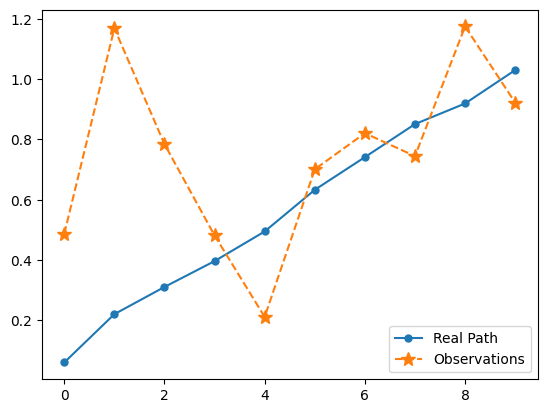

In [79]:
def simulate_realworld_neato(sensor_var, process_var, vel=1.0, step=1, dt=1.):
    """Simulates the movement of a Neato and measurement in the world.
    Input: 
        sensor_var
        process_var
        vel (float): velocity of the bot
        step (int): number of simulation snapshots
        dt (float): time delta between simulation snapshots
    Return:
        xs (array(float)): real positions
        zs (array(float)): observed positions
    """
    x = 0.  # initial position
    sensor_std = math.sqrt(sensor_var)  # compute sensor standard deviation from variance
    process_std = math.sqrt (process_var)  # compute process standard deviation from variance
    xs, zs = [] ,[]
    for i in range(step):
        v = vel + (np.random.randn() * process_std)
        x += v * dt  # simple velocity based update
        xs.append(x)
        zs.append(x + np.random.randn() * sensor_std)  # noise corrupted observation
    return np.array(xs), np.array(zs)

gt_xs, zs = simulate_realworld_neato(SENSOR_VAR, PROCESS_VAR, vel=VEL, step=STEP, dt=DT)
plt.plot(gt_xs, marker=".", ms=10, label="Real Path")
plt.plot(zs, linestyle="--", marker="*", ms=10, label="Observations")
plt.legend()
plt.show()

In [80]:
p = np.array([
    [0, 0          ],
    [0, PROCESS_VAR],
])

F = np.array([
    [1, DT],
    [0, 1 ],
])

H = np.array([[1, 0]])

R = np.array([[SENSOR_VAR]])

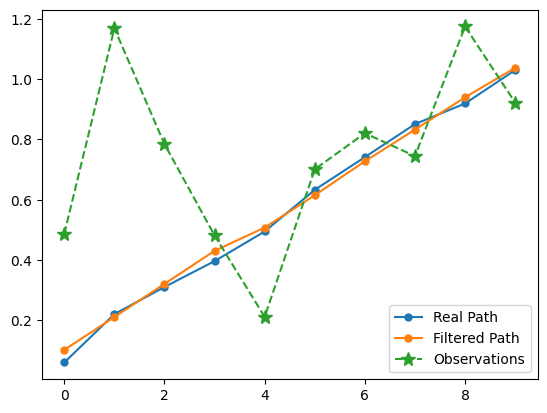

In [81]:
rng = np.random.default_rng()

filtered_xs: list[np.ndarray] = [np.array([0, VEL])]

for i in range(STEP):
    # Calculate w and Q for this timestep
    w = rng.normal(loc=[0, 0], scale=[0, PROCESS_VAR])
    q = np.cov(w)

    # Predict
    x_hat = F @ filtered_xs[i] # No actions and no noise
    p_hat = F @ p @ F.T + q

    # Update
    y = zs[i] - H @ x_hat
    s = H @ p @ H.T + R
    k = p_hat @ H.T @ np.linalg.inv(s)

    filtered_xs.append(x_hat + k @ y)
    p = (np.identity(2) - k @ H) @ p

filtered_xs.pop(0)

filtered_pos = [x[0] for x in filtered_xs]

plt.plot(gt_xs, marker=".", ms=10, label="Real Path")
plt.plot(filtered_pos, marker=".", ms=10, label="Filtered Path")
plt.plot(zs, linestyle="--", marker="*", ms=10, label="Observations")
plt.legend()
plt.show()